In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import os
os.getcwd()

'/home/jovyan/CN_A1_StructuralDescriptors'

In [3]:
G_raw = nx.read_pajek('activityA1/net1.net')
G = nx.Graph(G_raw)

In [6]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(num_nodes)
print(num_edges)

5000
25000


In [7]:
degrees = [degree for node, degree in G.degree()]
min_deg = np.min(degrees)
max_deg = np.max(degrees)
avg_deg = np.mean(degrees)
print(f"Grado mínimo: {min_deg}")
print(f"Grado máximo: {max_deg}")
print(f"Grado promedio: {avg_deg:.2f}")

Grado mínimo: 6
Grado máximo: 16
Grado promedio: 10.00


In [8]:
avg_clustering = nx.average_clustering(G)
print(f"Clustering promedio: {avg_clustering:.4f}")

Clustering promedio: 0.4141


In [9]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Asortatividad: {assortativity:.4f}")

Asortatividad: -0.0097


In [20]:
if nx.is_connected(G):
    G_main = G
else:
    print("La red está desconectada")
    largest_cc = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_cc)

avg_path = nx.average_shortest_path_length(G_main)
diameter = nx.diameter(G_main)
print(f"Longitud promedio del camino: {avg_path:.4f}")
print(f"Diámetro: {diameter}")


Longitud promedio del camino: 5.1211
Diámetro: 8


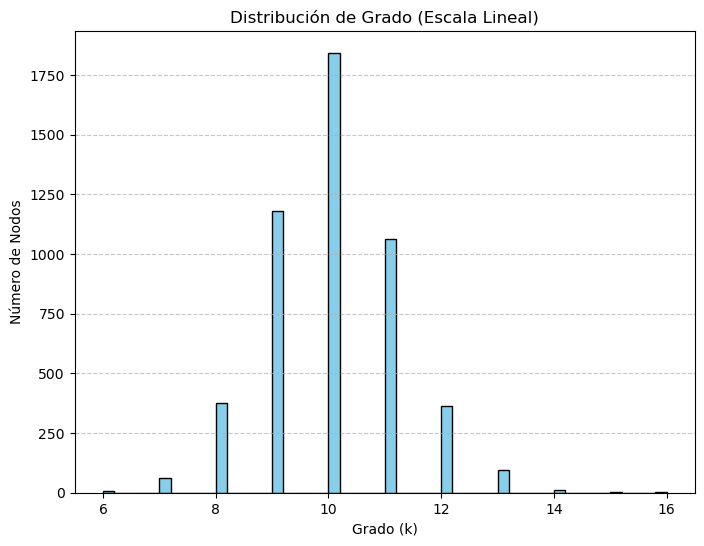

In [23]:
import matplotlib.pyplot as plt

# 1. Sacamos una lista plana con el grado de cada nodo
degrees = [degree for node, degree in G.degree()]

# 2. Preparamos el lienzo
plt.figure(figsize=(8, 6))

# 3. Dibujamos el histograma lineal
# 'bins' son las barras. Si la red es muy grande, igual quieres subir este número a 100
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')

# 4. Ponemos la gráfica bonita
plt.title('Distribución de Grado (Escala Lineal)')
plt.xlabel('Grado (k)')
plt.ylabel('Número de Nodos')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. ¡A printear!
plt.show()